### Plot all IRFs

Plot time series of IRF for all ice sheet models

To be included in appendix

In [1]:
import numpy as np
import xarray as xr
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

import sys
sys.path.append('../src')

from alldata import AllData

#np.set_printoptions(precision=2)
%matplotlib notebook
%matplotlib inline
%config InlineBackend.print_figure_kwargs={'bbox_inches':None}
%load_ext autoreload
%autoreload 2

Read data

In [2]:
ad = AllData()
ad.fitctrl = True
ad.usefanom = True
ad.gather(update=False)

#Omit invalid ism
ad.ds = ad.ds.drop_sel(ism='PISM_DMI')

Gathered all data


Figure settings

In [3]:
plt.style.use('../src/style_paper')

mpl.rc('figure.subplot',left=.15,top=.95)

Make and save figure

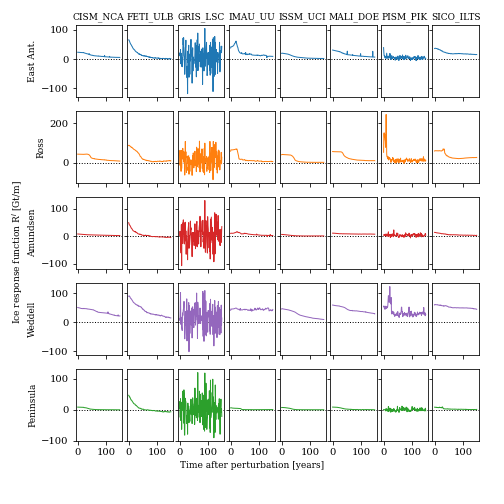

In [4]:
fig,ax = plt.subplots(5,8,figsize=(7,7),sharex=True,sharey='row')
for i,ii in enumerate(ad.ds.irf.ism.values):
    for b,bas in enumerate(ad.ds.irf.basin.values):
        ax[b,i].axhline(0,1,0,ls=':',c='k')
        ax[b,i].plot(ad.rftime,ad.ds.irf.sel(ism=ii,basin=bas).values,c=ad.bcol[bas],lw=1.)
        #ax[b,i].plot(ad.rftime,ad.irf[:,i,b],c=ad.bcol[bas],lw=1.5)
        
        if b==0:
            ax[b,i].set_title(ii)
        if i==0:
            ax[b,i].set_ylabel(bas)
ax[-1,3].set_xlabel('Time after perturbation [years]')
fig.supylabel(r'Ice response function R$^I$ [Gt/m]')

plt.savefig(f'../draftfigs/all_irfs.png')
plt.show()